In [ ]:
import numpy as np

from numpy.typing import NDArray
from numpy import float64

import gaussian.surrogate.gp as gp

mat1: NDArray[float64]  = np.array([.0, .1, .2, .3, .4])
mat2: NDArray[float64]  = np.array([.05, .15, .25, .35, .45])
y:    NDArray[float64]  = np.random.random((5,1))

(mean, cov, lmm) = gp.gaussian_surrogate(
    mat1=mat1,
    mat2=mat2,
    y=y,
    kernel=gp.squared_exponential,
    l=1.0,
    noise_var=1.0
)

print(mean)
print(cov)
print(lmm)



[[0.4518251 ]
 [0.43700308]
 [0.41776107]
 [0.39466702]
 [0.36839459]]
[[0.1857534  0.1740505  0.16054259 0.14563003 0.12974928]
 [0.1740505  0.17139019 0.1668423  0.16054259 0.15268164]
 [0.16054259 0.1668423  0.17139019 0.1740505  0.17474896]
 [0.14563003 0.16054259 0.1740505  0.1857534  0.19530676]
 [0.12974928 0.15268164 0.17474896 0.19530676 0.21374876]]


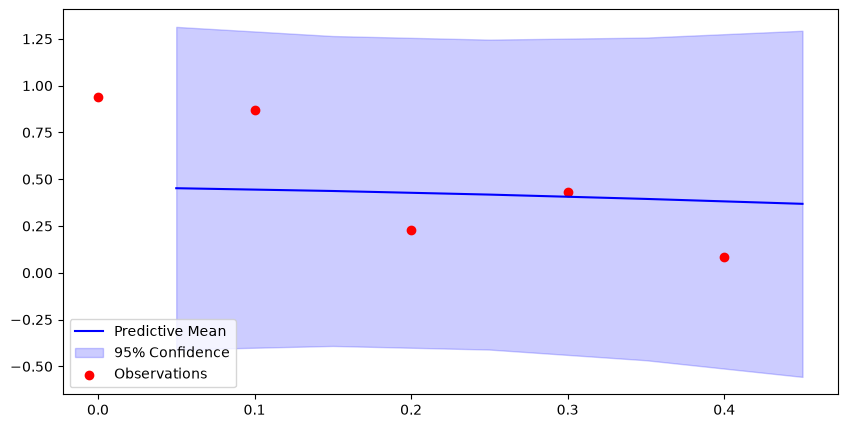

In [57]:
import matplotlib.pyplot as plt


def plot_gp(X_train, y_train, X_test, mu, cov):
    variance = np.diag(cov)
    std = np.sqrt(variance)
    
    plt.figure(figsize=(10, 5))
    plt.plot(X_test.flatten(), mu.flatten(), 'b-', label='Predictive Mean')
    
    plt.fill_between(
        X_test.flatten(), 
        (mu.flatten() - 2 * std), 
        (mu.flatten() + 2 * std), 
        color='blue', alpha=0.2, label='95% Confidence'
    )
    
    plt.scatter(X_train.flatten(), y_train.flatten(), c='red', label='Observations')
    
    plt.legend()
    plt.show()

plot_gp(
    X_train=mat1,
    y_train=y,
    X_test=mat2,

    mu=mean,
    cov=cov
)